In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ds = load_dataset("cambridgeltl/vsr_zeroshot")
df = ds["train"].to_pandas()

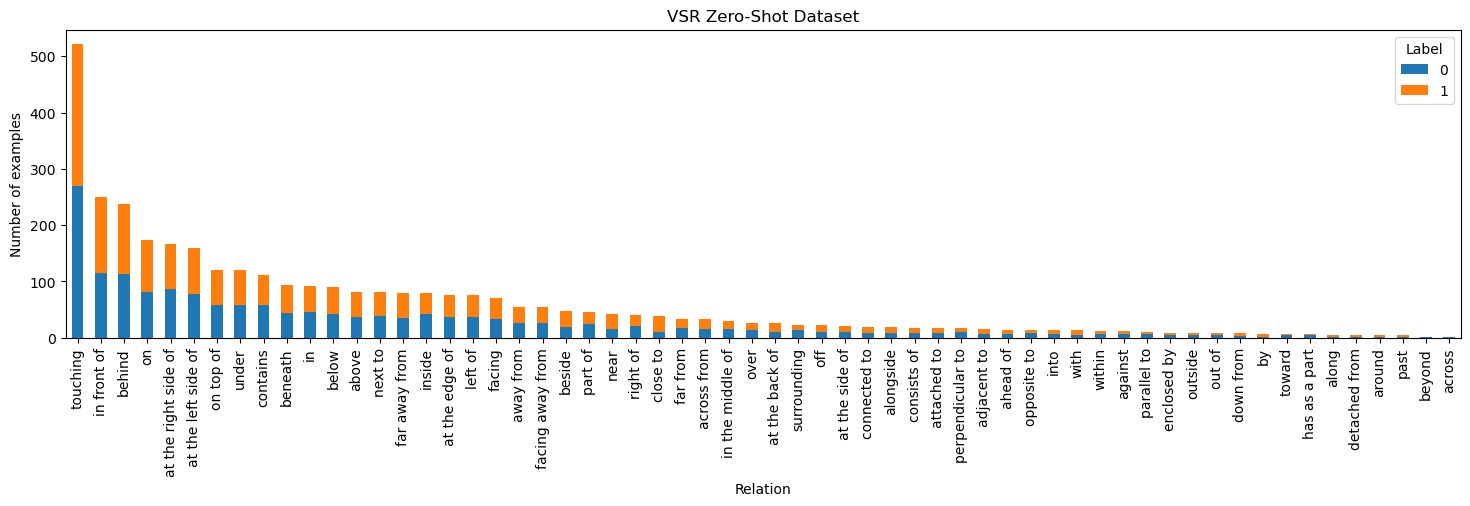

In [3]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['relation', 'label']].groupby(['relation', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Relation")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])

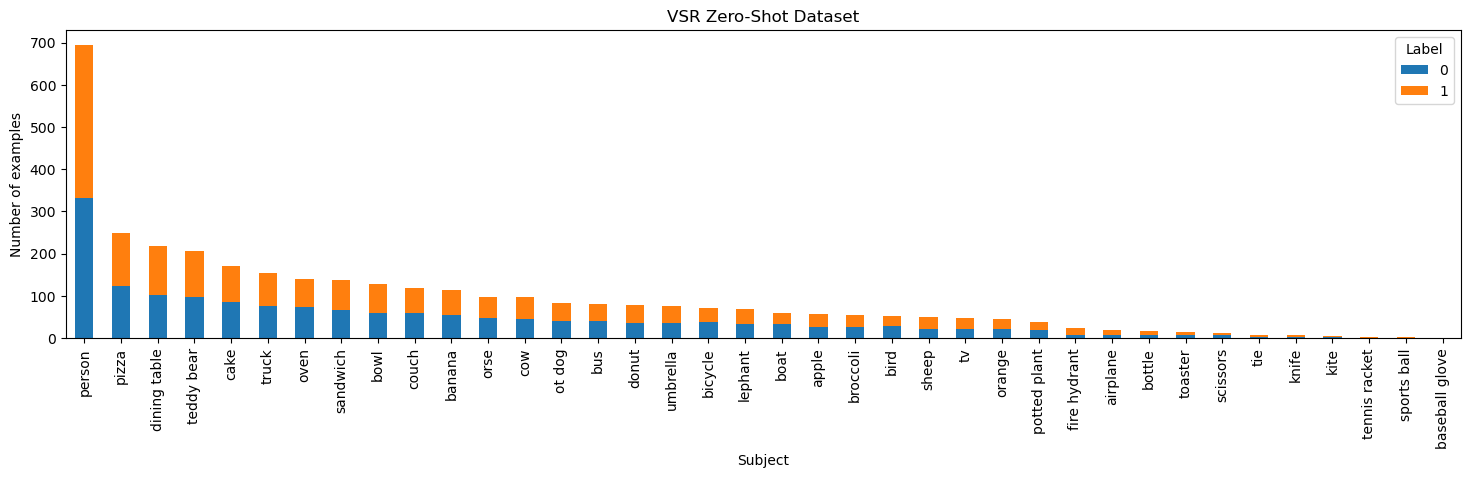

In [4]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['subj', 'label']].groupby(['subj', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Subject")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

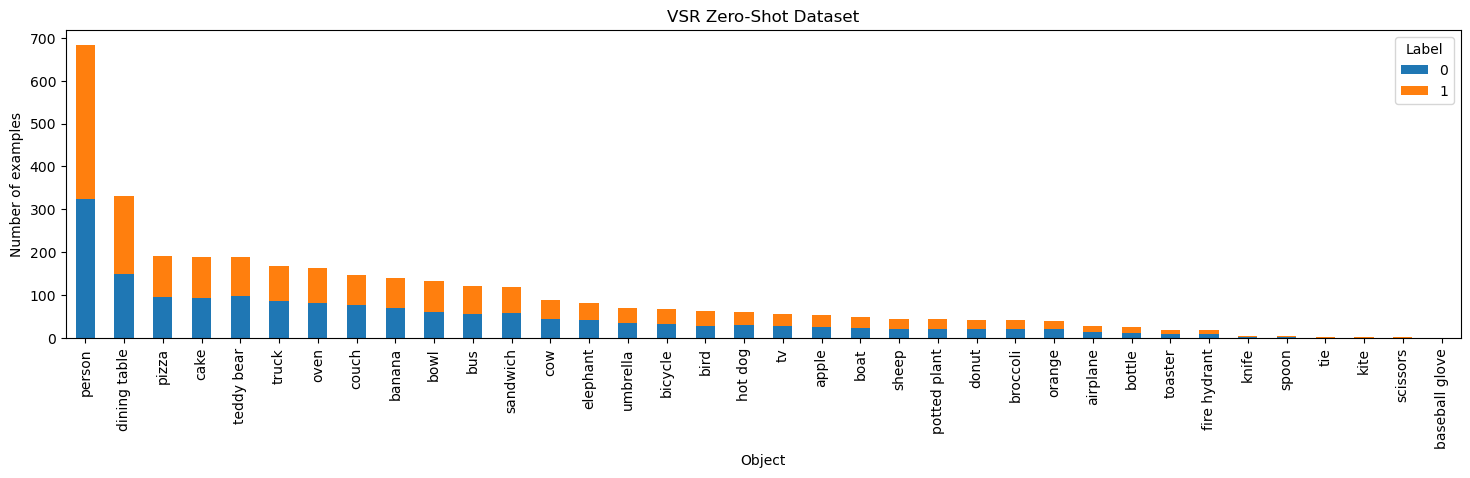

In [5]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['obj', 'label']].groupby(['obj', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Object")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

# Under-Sampling

In [6]:
def undersample_by_relation(df,
                            keep_ratio=0.8,
                            seed=42):
    """
    For the listed relations:
      • keep **all** rows where label == minority_label
      • keep only `keep_ratio` of rows where label != minority_label
    All other relations are left untouched.
    """
    
    # Empty DataFrame to store the new data
    df_biased = pd.DataFrame(columns=df.columns)

    for rel, group in df.groupby('relation'):
        # Split into minority / majority within this relation
        group_count = group['label'].value_counts()
        
        minority_label = group_count.idxmin()
        majority_label = group_count.idxmax()
        
        group_min = group[group['label'] == minority_label]
        group_maj = group[group['label'] == majority_label]
        
        # Remove random from minority
        n_keep = int(len(group_min) * keep_ratio)
        n_drop = len(group_min) - n_keep
        if n_drop > 0:
            group_min_to_keep = group_min.sample(n=n_keep, random_state=seed)
        else:
            group_min_to_keep = group_min.sample(n=0, random_state=seed)
            
        new_group = pd.concat([group_maj, group_min_to_keep])
        df_biased = pd.concat([df_biased, new_group])  
        
    df_biased['label'] = df_biased['label'].astype('int')    
    
    return df_biased.reset_index(drop=True)

# Example: make 'touching', 'in front of', 'on' mostly positive
df_relation_biased = undersample_by_relation(df,
                                             keep_ratio=0.8)



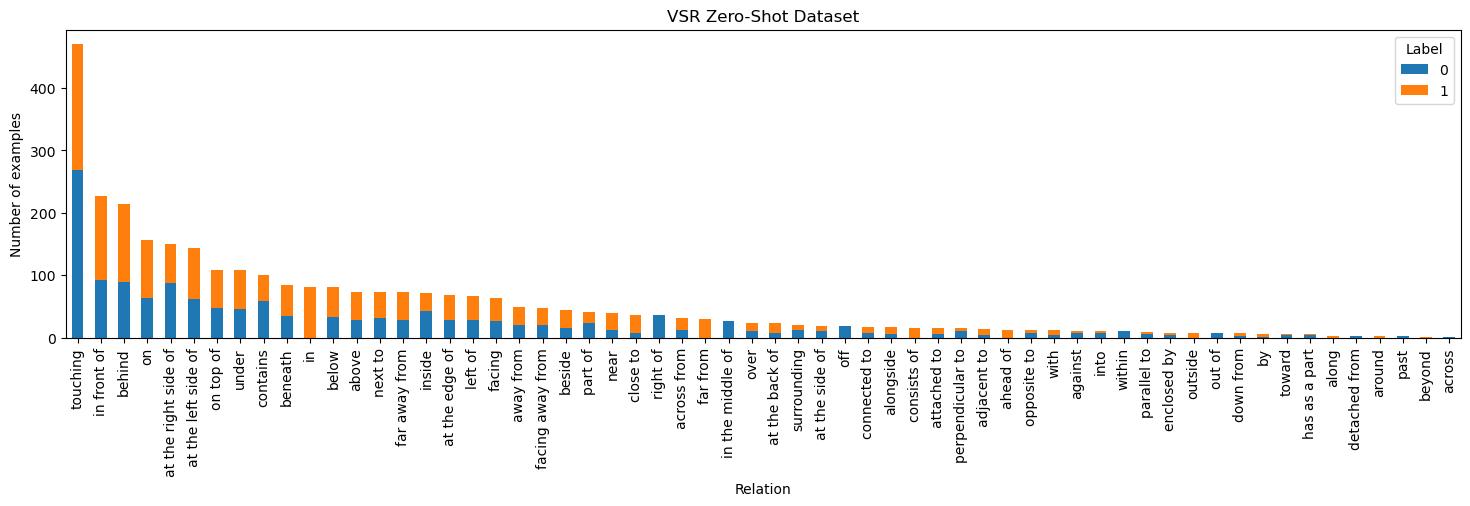

In [7]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df_relation_biased[['relation', 'label']].groupby(['relation', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Relation")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

In [11]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('label ~ relation', data=df_relation_biased).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  label   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     6.664
Date:                Mon, 05 May 2025   Prob (F-statistic):           3.22e-47
Time:                        14:41:20   Log-Likelihood:                -2077.3
No. Observations:                3137   AIC:                             4275.
Df Residuals:                    3077   BIC:                             4638.
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [12]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('label ~ relation', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  label   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.4648
Date:                Mon, 05 May 2025   Prob (F-statistic):               1.00
Time:                        14:41:20   Log-Likelihood:                -2516.7
No. Observations:                3489   AIC:                             5153.
Df Residuals:                    3429   BIC:                             5523.
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

# Add Vision Bias

In [ ]:
from datasets import load_from_disk
import os
from dotenv import load_dotenv
load_dotenv()

disk_loc = os.path.join(os.environ["DATA_PATH"], "vsr")

In [192]:
from datasets import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
import torch
import random

image_size = 32
batch_size = 64
num_workers = 8

def create_dataset(bias_prob=0.3, bias_strength=0.1, seed=42):
    random.seed(seed)
    torch.manual_seed(seed)

    dataset = load_from_disk(disk_loc)

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size), antialias=True),
        transforms.ToTensor(),          # → float tensor in [0,1]
    ])

    def add_pixel_values(example):
        img = Image.open(example["image_path"]).convert("RGB")
        px = transform(img)  # shape: (3, H, W), values in [0,1]

        # Subtle color bias: boost red for label 1, blue for label 0
        if random.random() < bias_prob:
            # add on random subset
            H, W = px.shape[1:]
            mask = torch.zeros((H, W), dtype=torch.bool)
            a = torch.randint(0, H, (int(H * W * 0.5),))
            b = torch.randint(0, W, (int(H * W * 0.5),))
            mask[a, b] = True
            
            if example["label"] == 1:
                px[0][mask] = torch.clamp(px[0][mask] + bias_strength, 0, 1)  # Subtract 5% green
            else:
                px[2][mask] = torch.clamp(px[2][mask] + bias_strength, 0, 1)  # Subtract 5% green

        example["pixel_values"] = px
        return example

    for split in dataset.keys():
        dataset[split] = dataset[split].map(
            add_pixel_values,
            remove_columns=["image_path"],              # drop once it’s inside pixel_values
            num_proc=num_workers,                       # parallel workers (optional)
        )

    # ------------------------------------------------------------------
    # 6. Tell datasets to yield PyTorch tensors
    # ------------------------------------------------------------------
    dataset.set_format(type="torch",
                    columns=["pixel_values", "label"], output_all_columns=False)  # include any columns you need


    loader_train = DataLoader(dataset['train'], batch_size=batch_size, num_workers=num_workers, shuffle=True, drop_last=True)
    loader_val = DataLoader(dataset['validation'], batch_size=batch_size, num_workers=num_workers, drop_last=False)
    loader_test = DataLoader(dataset['test'], batch_size=batch_size, num_workers=num_workers, drop_last=False)

    return loader_train, loader_val, loader_test

loader_train, loader_val, loader_test = create_dataset(bias_prob=0.3, bias_strength=0.1, seed=42)

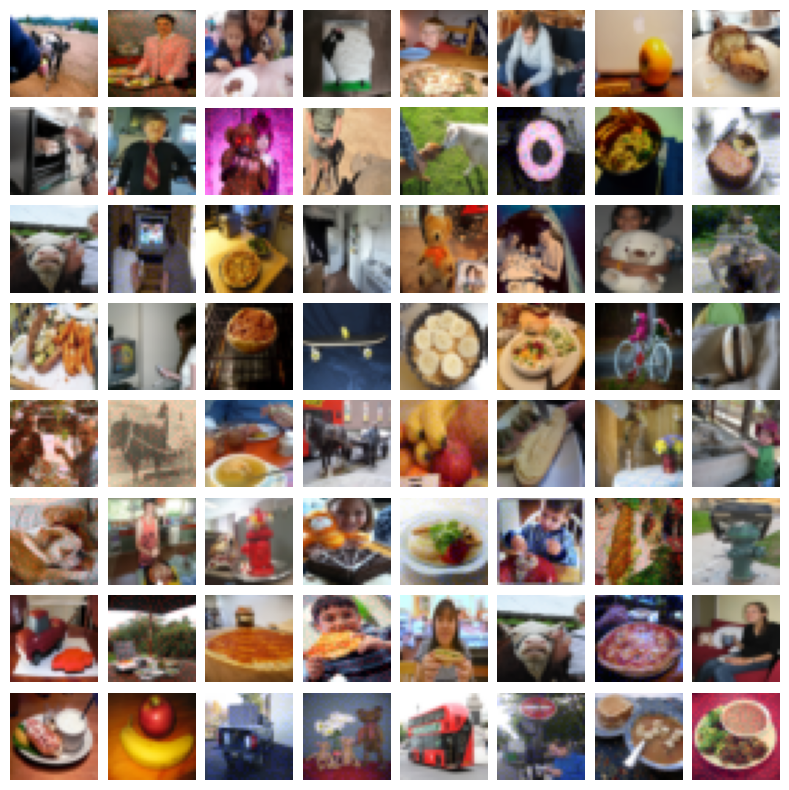

In [193]:
from mpl_toolkits.axes_grid1 import ImageGrid

batch      = next(iter(loader_train))
imgs       = batch["pixel_values"]      # (B, C, 14, 14)
cls_idxs   = batch["label"]             # (B,)

fig = plt.figure(figsize=(10, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(8, 8), axes_pad=0.1)

for ax, img in zip(grid, imgs):         # imgs is a tensor now
    ax.imshow(img.squeeze().permute(1,2,0).numpy(), cmap='gray')  # or .permute(1,2,0) for RGB
    ax.axis("off")

plt.show()


In [235]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=1, image_size=32):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(8 * (image_size // 2) * (image_size // 2), 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        
        x = self.fc3(x)
        x = self.dropout(x)
        
        return x
    
cnn = SimpleCNN(num_classes=1, image_size=image_size).to(device)

In [236]:
optimizer = torch.optim.AdamW(cnn.parameters())
num_parameters = sum([p.numel() for p in cnn.parameters()])
print(f'Number of parameters: {num_parameters:,}')

for bias_strength in [0.3, 0.1]:
    print(f"Bias strength: {bias_strength}")
    
    # 30% of the data is biased, meaning we should theoretically get 30% + 35% = 65% accuracy
    loader_train, loader_val, loader_test = create_dataset(bias_prob=0.3, bias_strength=bias_strength, seed=42)
    
    

    num_epochs = 7
    train_losses = []
    val_losses = []
    val_accuracies = []

    for _ in range(num_epochs):
        # Train loop
        cnn.train()
        epoch_loss_train = 0
        pbar = tqdm(total=len(loader_train))
        for batch in loader_train:        
            
            inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

            logits = cnn(inputs)
            
            # BCE loss
            loss = nn.BCEWithLogitsLoss()(logits, targets.float().unsqueeze(1))

            cnn.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            
            epoch_loss_train += loss.item()
            
            pbar.update(1)
            pbar.set_description(f'Train loss: {loss.item():.3f}')
        pbar.close()
        
        epoch_loss_train /= len(loader_train)
        train_losses.append(epoch_loss_train)
        
        
        # Validation loop
        cnn.eval()
        epoch_loss_val = 0
        correct = 0
        count = 0
        for batch in loader_val:
            inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

            with torch.no_grad():
                logits = cnn(inputs)
            
            loss = nn.BCEWithLogitsLoss()(logits, targets.float().unsqueeze(1))
        
            pred = (logits.squeeze() > 0).float()
            correct += pred.eq(targets.view_as(pred)).sum().item()
            
            epoch_loss_val += loss.item()
            count += len(pred)
            
        accuracy = correct / count
        
        epoch_loss_val /= len(loader_val)
        val_losses.append(epoch_loss_val)
        val_accuracies.append(accuracy)
        
        print(f'Train loss: {epoch_loss_train:.3f}, val loss: {epoch_loss_val:.3f}, val accuracy: {accuracy:.3f}')
torch.save(cnn.state_dict(), f"cnn_biased_30pct_strength_1.pth")

Number of parameters: 133,473
Bias strength: 0.3


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.689, val loss: 0.670, val accuracy: 0.656


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.667, val loss: 0.622, val accuracy: 0.653


...

Train loss: 0.636, val loss: 0.663, val accuracy: 0.603


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.644, val loss: 0.678, val accuracy: 0.588


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.627, val loss: 0.677, val accuracy: 0.576


In [237]:
from sklearn.metrics import classification_report

test_loss = 0
correct = 0
count = 0

preds = []
y_th = []

loader_train, loader_val, loader_test = create_dataset(bias_prob=0.3, bias_strength=0.1, seed=42)

cnn.eval()
for batch in loader_test:
    inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

    with torch.no_grad():
        logits = cnn(inputs)
    
    loss = nn.BCEWithLogitsLoss()(logits, targets.float().unsqueeze(1))
    test_loss += loss.item()
    
    pred = (logits.squeeze() > 0).float()
    correct += pred.eq(targets.view_as(pred)).sum().item()
    count += len(pred)
    
    preds.extend(pred.cpu().numpy())
    y_th.extend(targets.cpu().numpy())

test_loss /= len(loader_test)
accuracy = correct / count

print(f'Test loss: {test_loss:.3f}')
print(f'Test top-1 accuracy: {accuracy*100}%')

print(classification_report(y_th, preds, zero_division=0))

Test loss: 0.688
Test top-1 accuracy: 54.09165302782324%
              precision    recall  f1-score   support

           0       0.54      0.41      0.46       593
           1       0.54      0.66      0.60       629

    accuracy                           0.54      1222
   macro avg       0.54      0.54      0.53      1222
weighted avg       0.54      0.54      0.53      1222

